In [48]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n2)), str(id(n2)) + n2._op)
    return dot

In [148]:
class Value:
    def __init__(self, data, _children = (), label = '', grad = 0.0, _op = ''):
        self.data = data
        self._prev = set(_children)
        self.label = label
        self.grad = grad
        self._op = _op
        self._backward = lambda: None

    def __repr__(self):
        return f"Value {self.label} = {self.data}"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), _op = '+')

        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other),  _op = '*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out

    def tanh(self):
        t = (math.exp(2 * self.data) - 1) / (math.exp(2 * self.data) + 1)
        out = Value(t, (self, ), _op = 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        list = []
        set1 = set()
        topsort1 = self.topsort(list, set1)

        for i in range(len(topsort1)):
            topsort1[len(topsort1) - i - 1]._backward()

    def topsort(self, topsort = [], visited = set()):
        if self in visited:
            return
        
        visited.add(self)

        for child in self._prev:
            child.topsort(topsort, visited)
        topsort.append(self)
        return topsort

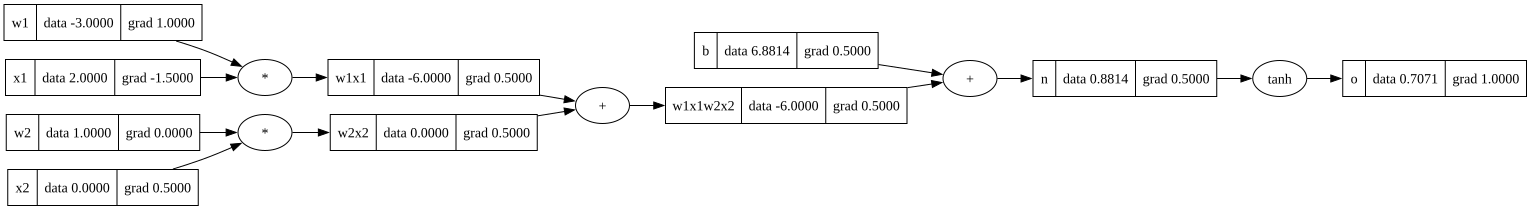

In [149]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

b = Value(6.8813735870195432, label = 'b')

w1x1 = w1 * x1; w1x1.label = 'w1x1'
w2x2 = w2 * x2; w2x2.label = 'w2x2'

w1x1w2x2 = w1x1 + w2x2; w1x1w2x2.label = 'w1x1w2x2'

n = w1x1w2x2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

o.grad = 1.0
# o._backward()
# n._backward()
# w1x1w2x2._backward()
# w1x1._backward()
o.backward()
draw_dot(o)

In [ ]:
a = b + c

da/db = 1
